## OTK 10: Napovedovanje stresa s strojnim učenjem

Machine learning models to predict stress

In [1]:

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline
sns.set_style('darkgrid')


In [2]:
def load_subj_data(directory, subject_id, sampling_ts, data_chest = 1, data_wrist = 1):
    d_subj = [] #pd.DataFrame()  
    d_T = []
    d_ts = []
    
    if data_wrist==1:
        d_w = pd.read_csv(directory + '/S' + str(subject_id) + '_W.csv')
        d_T = d_w['Target']
        d_ts = d_w['Unnamed: 0'] * sampling_ts     
        d_w.drop(['Unnamed: 0'], axis = 1, inplace= True)
        d_w.drop(['Target'], axis = 1, inplace= True)        
        
        d_subj = d_w   #pd.concat([d_subj, d_w])
        d_subj.describe()
        
    if data_chest==1:
        d_c = pd.read_csv(directory + '/S'  + str(subject_id) + '_C.csv')
        if len(d_T)==0:
            d_T = d_c['Target']
            d_ts = d_c['Unnamed: 0'] * sampling_ts     
        d_c.drop(['Unnamed: 0'], axis = 1, inplace= True)
        d_c.drop(['Target'], axis = 1, inplace= True)
        if len(d_subj)==0:
            d_subj = d_c
        else:
            d_subj = d_subj.join(d_c)
    
    d_subj = d_subj.join(d_ts)
    d_subj['ID'] = subject_id

    d_subj = d_subj.join(d_T)
    d_subj.rename(columns={'Unnamed: 0': "Time"}, inplace = True)
        
    return d_subj    

# TESTING
#dir1 = r'W:\\WESAD\\' + 'FEATURES_5s'
#d1test = load_subj_data(dir1, 2, 5, data_wrist=1, data_chest=1)
#d1test.describe()




In [9]:
# 1.1. PODATKI

# Nalozi feature podatke za vse subjekte v datas
# Nastavi pot do podatkov
data_set = r'FEATURES_s10_w30/'

# NOVO En dataframe za eno osebo !
FEATURESDIR =  'FEATURES_s10_w30/'  #'FEATURES_5s\\'
SUBJECTS_PLOT = [2,3,4,5,6,7,9,10]  #,6,7,9,10,11,13,14,15,16,17]
sampling_ts = 30
subject_id = 2

datas = []
for subjId in SUBJECTS_PLOT:
    
    d1subj = load_subj_data(data_set+FEATURESDIR, subjId, sampling_ts, data_wrist=0, data_chest=1)

    print("Oseba", subjId, "  shape:", d1subj.shape)
    datas.append(d1subj)
    
print('Stevilo dataframov: ', len(datas))

#
data = pd.concat(datas, axis=0, ignore_index=True)

# Stolpci v podatkih

data.describe()



Oseba 2   shape: (604, 62)
Oseba 3   shape: (646, 62)
Oseba 4   shape: (639, 62)
Oseba 5   shape: (622, 62)
Oseba 6   shape: (704, 62)
Oseba 7   shape: (520, 62)
Oseba 9   shape: (519, 62)
Oseba 10   shape: (546, 62)
Stevilo dataframov:  8


,ACC_X_mean_C,ACC_Y_mean_C,ACC_Z_mean_C,ACC_X_std_C,ACC_Y_std_C,ACC_Z_std_C,ACC_X_max_C,ACC_Y_max_C,ACC_Z_max_C,ACC_X_iabs_C,...,SCL_mean_C,SCR_std_C,SCL_std_C,SCR_peaks_C,EMG_mean_C,EMG_std_C,EMG_dynamic_range_C,Time,ID,Target
count,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,...,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000
mean,0.806104,-0.067375,-0.265712,0.020476,0.024561,0.053212,0.911106,0.178124,0.516252,24.183026,...,5.596451,0.000671,0.064154,2692.458958,-0.002947,0.015910,-4.064649,9081.343750,5.584792,1.286875
std,0.118432,0.103346,0.331351,0.029666,0.030780,0.072332,0.246571,0.213019,0.353355,3.553704,...,4.323143,0.000421,0.131490,29.061531,0.001030,0.011410,7.180092,5360.645953,2.572374,1.626641
min,0.366957,-0.485203,-0.881915,0.002509,0.002063,0.004026,0.380000,0.011800,0.059200,11.008195,...,0.388576,0.000206,0.004384,2613.000000,-0.009180,0.005715,-59.024124,0.000000,2.000000,0.000000
25%,0.752245,-0.098881,-0.485199,0.006070,0.005387,0.011783,0.819850,0.076000,0.322400,22.566273,...,1.648377,0.000331,0.010606,2675.000000,-0.003645,0.009380,-9.394479,4492.500000,3.000000,0.000000
50%,0.849666,-0.045037,-0.276798,0.010091,0.011917,0.021867,0.921000,0.139400,0.467900,25.488766,...,5.081229,0.000585,0.021093,2691.000000,-0.003019,0.012806,-4.855088,8985.000000,5.000000,1.000000
75%,0.896949,-0.013085,-0.066776,0.020774,0.031330,0.057231,0.977000,0.228000,0.680200,26.909283,...,8.168643,0.000910,0.072447,2708.000000,-0.002464,0.018213,1.048988,13477.500000,7.000000,2.000000
max,0.916246,0.205289,0.769618,0.471618,0.417221,0.559457,6.600000,6.600000,6.600000,28.000832,...,21.975067,0.006716,2.532846,2889.000000,0.002463,0.100833,20.914752,21090.000000,10.000000,7.000000


In [10]:
# 1.2. PODATKI - PREPROCESIRANJE 

def select_classes(data_1, param_class = 1):
    # Select classes for the analysis. 
    # Returns the data with the selected classes. The target is a categorical variable
    
    # ID of the respective study protocol condition, sampled at 700 Hz. The following IDs 
    # are provided: 0 = not defined / transient, 1 = baseline, 2 = stress, 3 = amusement, 
    # 4 = meditation, 5/6/7 = should be ignored in this dataset 

    if param_class == 0:
        # Nov klas 1 naj bo amusement, meditation
        # 0 vrze ven
        # 2 stres bo postal klas 0    
        data_1['Target'].replace(3,1, inplace = True)
        data_1['Target'].replace(4,1, inplace = True)
        data_1.drop(data_1.loc[data_1['Target'] == 0].index, axis = 0, inplace=True)
        data_1.drop(data_1.loc[data_1['Target'] > 2].index,axis=0,inplace = True)
        data_1['Target'] = data_1['Target'].replace(2,0)
        
        data_1.index=range(0,data_1.shape[0])

    if param_class == 1:
        # Clanek: class 0 non-stress: baseline, amusement
        # class 1: stres
        data_1.drop(data_1.loc[data_1['Target'] == 0].index, axis = 0, inplace = True)
        data_1.drop(data_1.loc[data_1['Target'] >= 4].index, axis=0, inplace = True)
        data_1['Target'] = data_1['Target'].replace(1,0)
        data_1['Target'] = data_1['Target'].replace(3,0)
        data_1['Target'] = data_1['Target'].replace(2,1)

        
    return data_1

cls_baseline_stress = 1
cls_stress_amusement = 0

# extract the data for the selected classes: baseline 0, stress 1
data = select_classes(data, cls_baseline_stress)

# Check for infinite or extremely large values and replace them with NaN
data.iloc[:, :-3] = data.iloc[:, :-3].replace([np.inf, -np.inf], np.nan)

# Drop rows with NaN values
data = data.dropna()

data.describe()

,ACC_X_mean_C,ACC_Y_mean_C,ACC_Z_mean_C,ACC_X_std_C,ACC_Y_std_C,ACC_Z_std_C,ACC_X_max_C,ACC_Y_max_C,ACC_Z_max_C,ACC_X_iabs_C,...,SCL_mean_C,SCR_std_C,SCL_std_C,SCR_peaks_C,EMG_mean_C,EMG_std_C,EMG_dynamic_range_C,Time,ID,Target
count,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,...,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000
mean,0.805312,-0.055993,-0.362068,0.011500,0.014410,0.025465,0.867756,0.138981,0.464885,24.158194,...,5.273219,0.000687,0.049536,2692.032000,-0.002821,0.013256,-4.115040,5873.691429,5.802857,0.295429
std,0.106235,0.117214,0.243088,0.013261,0.017273,0.033734,0.128148,0.113399,0.208551,3.186902,...,4.317022,0.000369,0.085666,29.092312,0.001114,0.006166,6.720152,4340.406504,2.639909,0.456366
min,0.499068,-0.485203,-0.820090,0.002509,0.002127,0.004026,0.551200,0.012600,0.063400,14.971313,...,0.564455,0.000207,0.004384,2613.000000,-0.004293,0.006719,-18.971475,210.000000,2.000000,0.000000
25%,0.716963,-0.065516,-0.543896,0.005097,0.005363,0.009422,0.779600,0.069800,0.284600,21.507880,...,1.582571,0.000339,0.009616,2675.000000,-0.003562,0.009330,-9.123466,2407.500000,4.000000,0.000000
50%,0.837768,-0.038154,-0.393571,0.007923,0.008990,0.016069,0.884200,0.101600,0.457400,25.131841,...,3.754987,0.000656,0.018116,2691.000000,-0.002964,0.011187,-5.333554,4215.000000,6.000000,0.000000
75%,0.899310,-0.000405,-0.175295,0.013408,0.017272,0.028057,0.953400,0.164950,0.642100,26.978025,...,8.161392,0.000914,0.060528,2708.000000,-0.002432,0.015332,0.471396,8602.500000,9.000000,1.000000
max,0.914999,0.205289,0.242182,0.147662,0.189833,0.354431,1.380600,0.622200,1.180200,27.448661,...,20.205940,0.001953,1.532716,2882.000000,0.002463,0.067725,18.361079,17730.000000,10.000000,1.000000


In [12]:
# 1.3. PODATKI - SKALIRANJE
!pip install scikit-learn

# Scaling features
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.preprocessing import Normalizer, QuantileTransformer, PowerTransformer


# A. No scaling
data_scaled = data.copy()

# B. Standard scaling
if False:
    standardScaler = StandardScaler()
    data_scaled = data.copy()
    data_scaled.iloc[:, :-3] = standardScaler.fit_transform(data.iloc[:, :-3])

# C. MinMax scaling
if False:
    minMaxScaler = MinMaxScaler()
    data_scaled = data.copy()

    data_scaled.iloc[:, :-3] = minMaxScaler.fit_transform(data.iloc[:, :-3])

if False:
    # D. Robust scaling
    robustScaler = RobustScaler()
    data_scaled = data.copy()

    data_scaled.iloc[:, :-3] = robustScaler.fit_transform(data.iloc[:, :-3])

if True:
    # E. Quantile scaling
    quantileScaler = QuantileTransformer()
    data_scaled = data.copy()
    data_scaled.iloc[:, :-3] = quantileScaler.fit_transform(data.iloc[:, :-3])
    
data_scaled.describe()


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\janez\AppData\Local\Temp\ipykernel_82992\3681622777.py:36: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.46346346 0.61561562 0.76976977 ... 0.76976977 0.18768769 0.61561562]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_scaled.iloc[:, :-3] = quantileScaler.fit_transform(data.iloc[:, :-3])


,ACC_X_mean_C,ACC_Y_mean_C,ACC_Z_mean_C,ACC_X_std_C,ACC_Y_std_C,ACC_Z_std_C,ACC_X_max_C,ACC_Y_max_C,ACC_Z_max_C,ACC_X_iabs_C,...,SCL_mean_C,SCR_std_C,SCL_std_C,SCR_peaks_C,EMG_mean_C,EMG_std_C,EMG_dynamic_range_C,Time,ID,Target
count,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,...,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000
mean,0.500001,0.499999,0.499998,0.499998,0.500002,0.500001,0.500005,0.500018,0.499993,0.500000,...,0.500004,0.499998,0.500003,0.499980,0.499998,0.500003,0.499998,5873.691429,5.802857,0.295429
std,0.288923,0.288922,0.288916,0.288919,0.288925,0.288922,0.288939,0.288934,0.288921,0.288923,...,0.288922,0.288921,0.288921,0.288898,0.288926,0.288920,0.288927,4340.406504,2.639909,0.456366
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,210.000000,2.000000,0.000000
25%,0.250172,0.249930,0.250118,0.249953,0.250213,0.250021,0.250250,0.250751,0.249249,0.250172,...,0.250009,0.250008,0.250183,0.251752,0.249978,0.250034,0.250172,2407.500000,4.000000,0.000000
50%,0.500071,0.499665,0.499809,0.499948,0.499848,0.500082,0.499499,0.498498,0.499499,0.500072,...,0.499951,0.500016,0.500388,0.497497,0.499950,0.499791,0.499810,4215.000000,6.000000,0.000000
75%,0.749790,0.749819,0.749800,0.749850,0.750105,0.750221,0.749750,0.750469,0.750441,0.749792,...,0.750222,0.749757,0.750100,0.752252,0.749900,0.750050,0.749796,8602.500000,9.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,17730.000000,10.000000,1.000000


In [13]:
# 1.4 Vizualizacija, PRIKAZ HISTOGRAMOV ZA EN SUBJECT

subject_ID = 3   # 

VISUALIZE_HIST = 0


data_subject = data_scaled.loc[data['ID'] == subject_ID]

if VISUALIZE_HIST == 1:
    
    for col in data_subject.columns[0:len(data_subject.columns)-3]:
        fg = sns.FacetGrid(data_subject, hue="Target", aspect=3)
        fg.map(sns.histplot, col, bins = 50, kde=True).add_legend()
        plt.title(col + ' - subject ' + str(subject_ID))
        plt.show()
    

In [14]:
# 1.5 PRIKAZ HISTOGRAMOV ZA VSE SUBJECTE
# All subjects
USE_ALL_SUBJECTS = 1
if USE_ALL_SUBJECTS == 1:
    data_subject = data_scaled

    if VISUALIZE_HIST == 1:
        
        for col in data_subject.columns[0:len(data_subject.columns)-3]:
            fg = sns.FacetGrid(data_subject, hue="Target", aspect=3)
            fg.map(sns.histplot, col, bins = 50, kde=True).add_legend()
            plt.title(col + ' - ALL ')
            plt.show()


In [16]:
# Optional 
# Plot boxplot for each feature

if False:

    column_names = data_subject.columns[0:len(data_subject.columns)-3].to_list()
    print(column_names)

    for col in column_names[0:10]:
        fg = sns.FacetGrid(data_subject, aspect=1, palette="Set1", sharex=True, sharey=True, height=2.5)
        fg.map(sns.boxplot, x='Target', hue='Target', y=col, data=data_subject, palette="Set3", dodge=True, linewidth=0.5, width=0.5)
        #fg.add_legend()
        plt.title(col + ' - subject ' + str(subject_ID), fontsize=10)



                 Feature      F-Score        p-Value  Mutual Information  \
32      resp_E_std_dur_C  1437.096961  5.071422e-230            0.301498   
13          ACC_3D_std_C   987.366195  3.397194e-172            0.262825   
48             EDA_C_std   924.967412  1.992137e-163            0.215346   
54             SCL_std_C   873.280458  5.238536e-156            0.201036   
41          resp_I_std_C   835.375097  1.797228e-150            0.204289   
42          resp_E_std_C   792.801981  3.712591e-144            0.187222   
36         resp_volume_C   722.589544  1.661301e-133            0.196009   
35     resp_E_ampl_max_C   699.051043  7.231985e-130            0.263300   
34     resp_I_ampl_max_C   684.279332  1.448169e-127            0.251360   
3            ACC_X_std_C   670.309968  2.240426e-125            0.202792   
31      resp_I_std_dur_C   580.111627  6.331346e-111            0.145879   
33       resp_IE_ratio_C   553.472360  1.504710e-106            0.163892   
40         r

Text(0.5, 1.0, 'F-Score for each feature')

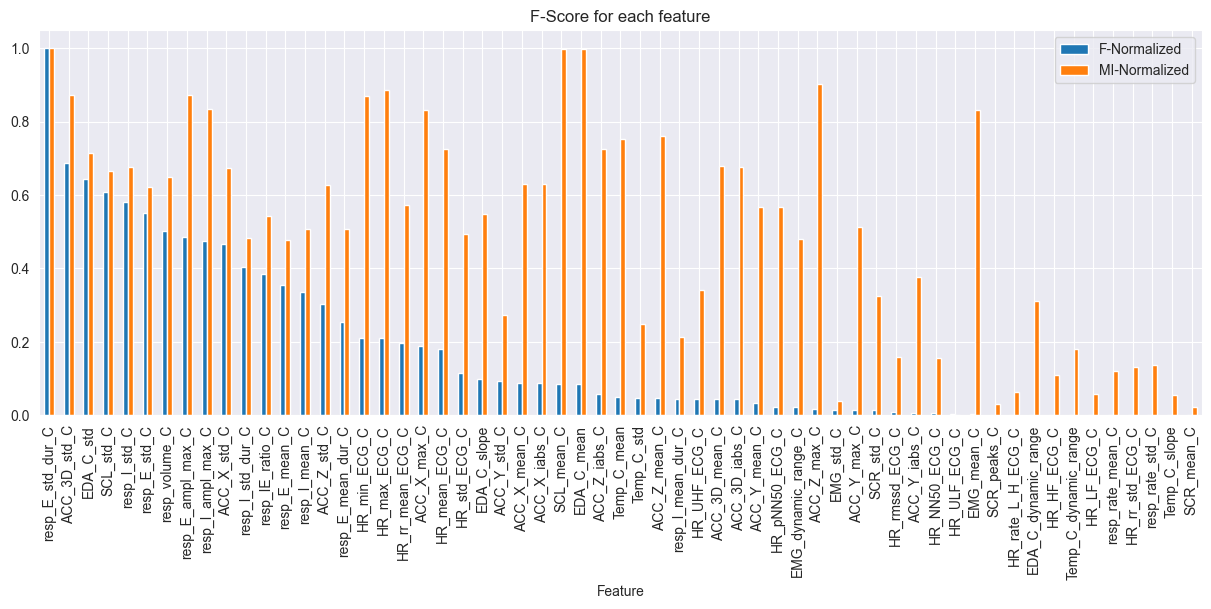

In [17]:

# 1.6. FEATURE SELECTION
# Feature selection using ANOVA F-test and mutual information

from sklearn.feature_selection import f_classif
from sklearn.feature_selection import mutual_info_classif


X_data = data_subject.iloc[:, :-3]  # Features (all columns except the last three)
Y_data = data_subject['Target']  # Target variable (last column)

# Compute ANOVA F-values for each feature
f_values, p_values = f_classif(X_data, Y_data)


# Compute mutual information for each feature
mi_scores = mutual_info_classif(X_data, Y_data)


# Create a DataFrame for better visualization
feature_scores = pd.DataFrame({'Feature': X_data.columns, 'F-Score': f_values, 'p-Value': p_values, 'Mutual Information': mi_scores})
feature_scores.sort_values(by='F-Score', ascending=False, inplace=True)

feature_scores['F-Normalized'] = feature_scores['F-Score'] / feature_scores['F-Score'].max()
feature_scores['MI-Normalized'] = feature_scores['Mutual Information'] / feature_scores['Mutual Information'].max()

print(feature_scores)

feature_scores.plot.bar(x = 'Feature', y = ['F-Normalized','MI-Normalized'], figsize=(15, 5))
plt.title('F-Score for each feature')

### 2. Machine learning

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, GridSearchCV, train_test_split, StratifiedKFold
from sklearn.metrics import (r2_score, mean_squared_error, accuracy_score, 
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, average_precision_score,
                             precision_recall_curve)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, average_precision_score
import matplotlib.pyplot as plt

#import os
#os.environ['KMP_DUPLICATE_LIB_OK']='True'
#%matplotlib inline

In [11]:
# 2.1 DEFINE TRAIN AND TEST DATA
# Split the data into features and target variable

Y_data = data_subject['Target']
X_data = data_subject.drop(['Target', 'ID', 'Time'], axis=1)

# Split the data into training and testing sets
x_tr, x_te, y_tr, y_te = train_test_split(X_data, Y_data, test_size = 0.4)

# Stratified KFold
cv = StratifiedKFold(n_splits=5, shuffle=True)

In [12]:
# Print train and test statistics
print('Train data: ', x_tr.shape, y_tr.shape)
print('Test data: ', x_te.shape, y_te.shape)

x_tr.describe()

Train data:  (1050, 59) (1050,)
Test data:  (700, 59) (700,)


,ACC_X_mean_C,ACC_Y_mean_C,ACC_Z_mean_C,ACC_X_std_C,ACC_Y_std_C,ACC_Z_std_C,ACC_X_max_C,ACC_Y_max_C,ACC_Z_max_C,ACC_X_iabs_C,...,EDA_C_dynamic_range,EDA_C_slope,SCR_mean_C,SCL_mean_C,SCR_std_C,SCL_std_C,SCR_peaks_C,EMG_mean_C,EMG_std_C,EMG_dynamic_range_C
count,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,...,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000
mean,0.506434,0.496882,0.504699,0.499961,0.496124,0.503713,0.501310,0.496250,0.494523,0.506434,...,0.488169,0.498102,0.509232,0.512443,0.490101,0.505240,0.494195,0.494827,0.494289,0.503740
std,0.287606,0.287369,0.286246,0.288194,0.288369,0.286883,0.285587,0.287859,0.284320,0.287605,...,0.292869,0.288459,0.286021,0.290853,0.291083,0.287053,0.287141,0.293409,0.290087,0.289983
min,0.000000,0.001149,0.000000,0.001038,0.000000,0.000574,0.000000,0.000000,0.000000,0.000000,...,0.001001,0.002129,0.000000,0.000774,0.002139,0.000000,0.000211,0.000000,0.000404,0.001001
25%,0.257379,0.252990,0.256219,0.248229,0.233690,0.258421,0.254254,0.255756,0.249249,0.257378,...,0.231350,0.254755,0.270156,0.257497,0.234538,0.258966,0.251752,0.232413,0.237354,0.255296
50%,0.514211,0.500430,0.511826,0.501527,0.491469,0.504208,0.503504,0.487487,0.486690,0.514211,...,0.483882,0.492242,0.509067,0.521442,0.481192,0.497842,0.478478,0.490370,0.496755,0.513943
75%,0.756191,0.743105,0.751749,0.749846,0.750105,0.752864,0.749750,0.741867,0.741255,0.756191,...,0.741172,0.739685,0.762715,0.768763,0.750304,0.754509,0.740741,0.746105,0.744921,0.754203
max,1.000000,1.000000,0.998850,0.997127,1.000000,0.998002,0.997998,1.000000,0.998999,1.000000,...,1.000000,0.999939,0.998916,1.000000,0.999345,0.999168,1.000000,1.000000,1.000000,1.000000


In [ ]:

# Examples how to define the models

models = {
    'LR': Pipeline([('scaler', StandardScaler()),  ('log_reg', LogisticRegression())]),
    'RF': Pipeline([('scaler', StandardScaler()),  ('RF', RandomForestClassifier())]),
    'LDA': Pipeline([('scaler', StandardScaler()),  ('LDA', LinearDiscriminantAnalysis())]),
    'QDA': Pipeline([('scaler', StandardScaler()),  ('QDA', QuadraticDiscriminantAnalysis())])
}

parameters = {
    'LR': {
        'log_reg__penalty': ['l1', 'l2'],
        'log_reg__C': [10, 5, 3, 1],
#         'pca__n_components': [5, 20, 30, 40, 50, 64]
    },
    'RF': {
        'RF__max_depth': [2, 5, 8], 
        'RF__n_estimators': [100, 500, 800],
#         'pca__n_components': [5, 20, 30, 40, 50, 64]
    },
    'XGB': {
        'XGB__max_depth': [2, 5, 8],
        'XGB__n_estimators': [100, 500, 800],
#         'pca__n_components': [5, 20, 30, 40, 50, 64]
    },
    'LDA': {
#         'pca__n_components': [5, 20, 30, 40, 50, 64]
        
    },
    'QDA': {
#         'pca__n_components': [5, 20, 30, 40, 50, 64]
        
    }
}



In [14]:
# 2.2 DEFINE TEST MACHINE LEARNING MODELS
# Tested models and parameters

models = {
    'LR': Pipeline([('log_reg', LogisticRegression())]),
    #'LR': Pipeline([('scaler', StandardScaler()),  ('log_reg', LogisticRegression())]),
     # 'DT': Pipeline([('scaler', StandardScaler()),  ('DT', tree.DecisionTreeClassifier())])
}

parameters = {
    'LR': {
        'log_reg__penalty': ['l2'],
        'log_reg__C': [10, 5, 3, 1],
        # 'pca__n_components': [5, 20, 30, 40, 50, 64]
    },
    
    'DT': {
        #'max_depth': [5,10,20]
     
        # 'pca__n_components': [5, 20, 30, 40, 50, 64]
    }    
}


In [15]:
# 2.3 Additional methods for model evaluation
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay, classification_report, confusion_matrix
import seaborn as sns


def print_results(name, y_te, prob_te, pred_te, params, time):
    roc_te = roc_auc_score(y_te, prob_te)
    ac_te = accuracy_score(y_te, pred_te)
    f1_te = f1_score(y_te, pred_te)
    print('{} with params: {}'.format(name, params[name]))
    print('\t                 Value')
    print('\tAccuracy:        {:.3f}'.format(ac_te))
    print('\tF1 score:        {:.3f}'.format(f1_te))
    print('\tROC_AUC:         {:.3f}'.format(roc_te))
    print('\tFit duration:    {:.3f}'.format(time))

def draw_pr_curve(recall, precision, average_precision):
    
    plt.step(recall, precision, color='b', alpha=0.2,
         where='post')
    plt.fill_between(recall, precision, step='post', alpha=0.2,
                     color='b')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall curve: AP={0:0.2f}'.format(
              average_precision))
    plt.show()
    
    
def print_stats_threshold(y_te, y_prob, thr):
    y_res = y_prob > thr
    
    print(classification_report(y_te, y_res))
    print('roc_auc \t {0:0.3f}'.format(roc_auc_score(y_te, y_prob)))
    
    # Draw precision-recall curve
    precision, recall, _ = precision_recall_curve(y_te, y_prob)
    draw_pr_curve(recall, precision, average_precision_score(y_te, y_res))
    
    # Draw confusion matrix
    sns.heatmap(confusion_matrix(y_te, y_res), annot=True, fmt="d")
    plt.show()
    

def print_stats (classifier, model_name, x_test, y_test, y_pred, num_classes = 2, normalize_cf=None, data_labels = []):
    
    print(classification_report(y_test, y_pred, digits = 3))
        
    plt.figure(figsize=(12,3))
    ax1 = plt.subplot(1,4,1)

    if num_classes <= 2:
        display = PrecisionRecallDisplay.from_estimator(
            classifier, x_test, y_test, name=model_name, plot_chance_level=True, ax=ax1
        )
        _ = display.ax_.set_title("2-class Precision-Recall curve")
    ax2 = plt.subplot(1,4,2)

    if num_classes <= 2:
        svc_disp = RocCurveDisplay.from_estimator(classifier, x_test, y_test, ax=ax2)    
    else:
        sns.heatmap(confusion_matrix(y_test, y_pred, normalize='pred'), annot=True, fmt="1.3f", cmap="PiYG")
        ax3.set_xlabel('Precision')


    ax3 = plt.subplot(1,4,3)
    sns.heatmap(confusion_matrix(y_test, y_pred, normalize='true'), annot=True, fmt="1.3f", cmap="PiYG" ) #, yticklabels=d_labP, xticklabels=d_labT)
    ax3.set_xlabel('Recall')


    ax4 = plt.subplot(1,4,4)
    ConfusionMatrixDisplay.from_estimator(classifier, x_test, y_test,  ax=ax4)
    
    plt.show()    


 *****************     Fitting model: LR
For LR best estimator = Pipeline(steps=[('log_reg', LogisticRegression(C=10))]) 
best params = {'log_reg__C': 10, 'log_reg__penalty': 'l2'}
              precision    recall  f1-score   support

           0      0.980     0.980     0.980       499
           1      0.950     0.950     0.950       201

    accuracy                          0.971       700
   macro avg      0.965     0.965     0.965       700
weighted avg      0.971     0.971     0.971       700



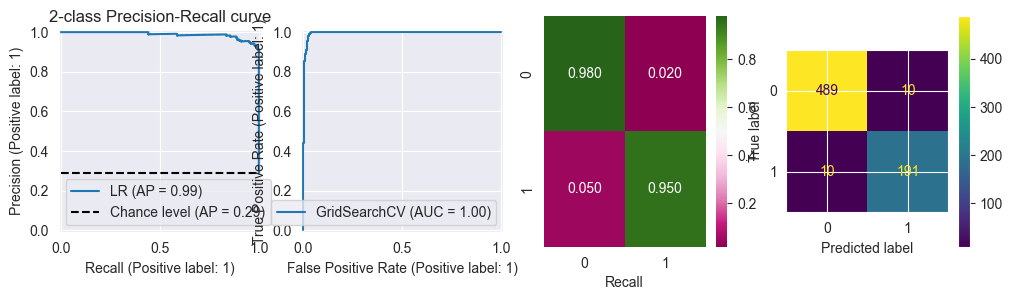

LR with params: {'log_reg__penalty': ['l2'], 'log_reg__C': [10, 5, 3, 1]}
	                 Value
	Accuracy:        0.971
	F1 score:        0.950
	ROC_AUC:         0.996
	Fit duration:    0.000
----------------------------------------------------------------------------------------



In [16]:
# 2.4 FIT THE MODEL AND evaluate the model
# Fit the model and predict

for model_name in models.keys():
    
    print('\n *****************     Fitting model: ' + model_name)
    #warnings.simplefilter(action='ignore')
    
    # Fit the model
    clf = GridSearchCV(models[model_name], parameters[model_name],
                       cv=cv, n_jobs=-1, scoring = 'f1')
    clf.fit(x_tr, y_tr)
    print ('For {} best estimator = {} \nbest params = {}'.format(model_name, clf.best_estimator_, clf.best_params_))
    
    # Prediction part
    y_pred = clf.predict(x_te)
    y_prob = clf.predict_proba(x_te)[:,1]
    #labels_proba[model_name + '_te'] = y_prob
    #labels_predict[model_name + '_te'] = clf.predict(x_te)
    
    print_stats(clf, model_name=model_name, x_test=x_te, y_test=y_te, y_pred=y_pred, num_classes=2)
    # print_stats_threshold(y_te, y_prob, 0.5)
    
    print_results(model_name, y_te, y_prob, y_pred, parameters, 0)
    print('----------------------------------------------------------------------------------------\n')

In [19]:
# 2.5 DIFFERENT TRAIN AND TEST SUBJECTS
USE_TEST_SUBJECTS = 0

if USE_TEST_SUBJECTS == 1:

    TRAIN_SUBJECTS = [3,4,5,6]  #,6,7,9,10,11,13,14,15,16,17]
    TEST_SUBJECTS = [7,9, 2]  #,6,7,9,10,11,13,14,15,16,17]

    # Split the data into training and testing sets by subject ID

    tr_index =data_subject['ID'].isin(TRAIN_SUBJECTS)
    te_index = data_subject['ID'].isin(TEST_SUBJECTS)

    x_tr = X_data.loc[tr_index]
    x_te = X_data.loc[te_index]   
    y_tr = Y_data.loc[tr_index]
    y_te = Y_data.loc[te_index]   

    # random splitting : x_tr, x_te, y_tr, y_te = train_test_split(X_data, Y_data, test_size = 0.4)

    # Stratified KFold
    cv = StratifiedKFold(n_splits=5, shuffle=True)



In [20]:
# Fit the model and predict
if USE_TEST_SUBJECTS == 1:

    for model_name in models.keys():
        
        print('\n *****************     Fit ' + model_name)
        #warnings.simplefilter(action='ignore')
        
        # Fit the model
        clf = GridSearchCV(models[model_name], parameters[model_name],
                        cv=cv, n_jobs=-1,scoring = 'f1')
        clf.fit(x_tr, y_tr)
        print ('For {} best estimator = {} \nbest params = {}'.format(model_name, clf.best_estimator_, clf.best_params_))
        
        # Prediction part
        y_pred = clf.predict(x_te)
        y_prob = clf.predict_proba(x_te)[:,1]
        #labels_proba[model_name + '_te'] = y_prob
        #labels_predict[model_name + '_te'] = clf.predict(x_te)
        
        print_stats(clf, model_name=model_name, x_test=x_te, y_test=y_te, y_pred=y_pred, num_classes=2)
        # print_stats_threshold(y_te, y_prob, 0.5)
        
        print_results(model_name, y_te, y_prob, y_pred, parameters, 0)
        print('----------------------------------------------------------------------------------------\n')